# Notebook 04 — SARIMA

Este notebook implementa el modelo SARIMA para la predicción de la
huella de carbono operacional del sistema eléctrico español con
resolución horaria (1h).

SARIMA extiende ARIMA añadiendo una componente estacional explícita,
lo que permite capturar el patrón diario de la serie directamente.
Con resolución horaria el periodo estacional es s=24 (un día completo),
lo que reduce considerablemente el coste computacional respecto a
s=96 con resolución de 15 minutos y permite usar auto_arima estacional
y 45 evaluaciones walk-forward.

**Evaluación:** walk-forward con 45 evaluaciones distribuidas por 2024,
paso de 8 días (no múltiplo de 7 para evitar sesgo por día de la semana),
ventana expansiva.

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dataclasses import dataclass
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8")
%matplotlib inline

BASE_DIR    = Path("/srv/TFM") if Path("/srv/TFM").exists() else Path("/home/ubuntu/TFM")
DATA_DIR    = BASE_DIR / "notebooks/data_processed"
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True, parents=True)
FIG_DIR     = BASE_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True, parents=True)

print("BASE_DIR:", BASE_DIR)
print("Existe:", BASE_DIR.exists())

BASE_DIR: /home/ubuntu/TFM
Existe: True


## 1. Carga de datos

Se cargan los parquets generados en el notebook 01 a resolución horaria (1h).
La división temporal es idéntica a la del resto de modelos:
- Train: 2022–2023 (~17.520 observaciones)
- Validación: 2024 (~8.784 observaciones)
- Test: 2025

In [2]:
y_train = pd.read_parquet(DATA_DIR / "train_2022_2023.parquet")["y"].astype(float)
y_val   = pd.read_parquet(DATA_DIR / "val_2024.parquet")["y"].astype(float)
y_test  = pd.read_parquet(DATA_DIR / "test_2025.parquet")["y"].astype(float)

y_train.index = pd.to_datetime(y_train.index)
y_val.index   = pd.to_datetime(y_val.index)
y_test.index  = pd.to_datetime(y_test.index)

print("Train:", y_train.shape, "|", y_train.index.min(), "->", y_train.index.max())
print("Val:  ", y_val.shape,   "|", y_val.index.min(),   "->", y_val.index.max())
print("Test: ", y_test.shape,  "|", y_test.index.min(),  "->", y_test.index.max())

Train: (17520,) | 2022-01-01 00:00:00+00:00 -> 2023-12-31 23:00:00+00:00
Val:   (8784,) | 2024-01-01 00:00:00+00:00 -> 2024-12-31 23:00:00+00:00
Test:  (8760,) | 2025-01-01 00:00:00+00:00 -> 2025-12-31 23:00:00+00:00


## 2. Configuración temporal y métricas

Con resolución horaria (1h):
- 1 hora = 1 paso
- 24 horas = 24 pasos (periodo estacional diario)
- 48 horas = 48 pasos
- 72 horas = 72 pasos

El periodo estacional s=24 es la clave de este notebook — con resolución
de 15 minutos era s=96, lo que hacía auto_arima estacional inviable
computacionalmente. Con s=24 el coste se reduce 4 veces.

In [3]:
FREQ_MIN        = 60
STEPS_PER_HOUR  = 1
SEASONAL_PERIOD = 24  # 24 pasos = 1 día

HORIZONS = {
    "48h": 48,
    "72h": 72,
}

@dataclass
class WFConfig:
    step: int
    min_history: int
    max_fits: int

def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {"MAE": mae, "RMSE": rmse}

print("Periodo estacional:", SEASONAL_PERIOD)
print("Horizontes:", HORIZONS)

Periodo estacional: 24
Horizontes: {'48h': 48, '72h': 72}


## 3. Selección del orden SARIMA con auto_arima estacional

Con resolución horaria y s=24 el coste computacional de auto_arima
estacional es asumible. Se usa una muestra de los últimos 90 días
de entrenamiento para la búsqueda del orden óptimo. Se limita el
espacio de búsqueda a órdenes parsimoniosos (max_p=3, max_q=2,
max_P=2, max_Q=1) para garantizar la estabilidad de los modelos
en el walk-forward posterior.

In [ ]:
from pmdarima import auto_arima

sample = y_train.iloc[-90 * SEASONAL_PERIOD:]
print(f"Muestra para auto_arima: {len(sample)} observaciones ({len(sample)//24} días)")

print(f"Muestra para auto_arima: {len(sample)} observaciones ({len(sample)//24} días)")
print("Buscando orden óptimo con auto_arima estacional (s=24)...")

auto_model = auto_arima(
    sample.values,
    start_p=0, max_p=3,
    start_q=0, max_q=2,
    d=None,
    start_P=0, max_P=2,
    start_Q=0, max_Q=1,
    D=0,
    seasonal=True,
    m=24,
    information_criterion="aic",
    stepwise=True,
    suppress_warnings=True,
    error_action="ignore",
    verbose=False
)
print(auto_model.summary())
sarima_order          = auto_model.order
sarima_seasonal_order = auto_model.seasonal_order
print(f"\nOrden seleccionado: SARIMA{sarima_order}x{sarima_seasonal_order}")

Muestra para auto_arima: 2160 observaciones (90 días)
Buscando orden óptimo con auto_arima estacional (s=24)...
                                     SARIMAX Results                                      
Dep. Variable:                                  y   No. Observations:                 2160
Model:             SARIMAX(1, 1, 1)x(1, 0, 1, 24)   Log Likelihood               -6740.298
Date:                            Thu, 14 May 2026   AIC                          13490.597
Time:                                    16:56:37   BIC                          13518.984
Sample:                                         0   HQIC                         13500.979
                                           - 2160                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar

In [5]:
cfg_sarima = WFConfig(
    step=8 * SEASONAL_PERIOD,
    min_history=7 * SEASONAL_PERIOD,
    max_fits=45
)

PLOT_INDICES = [2, 15, 30, 42]

def walk_forward_splits(series, horizons, cfg):
    n     = len(series)
    max_h = max(horizons.values())
    points = list(range(cfg.min_history, n - max_h, cfg.step))
    points = points[:cfg.max_fits]
    for t0 in points:
        train_part = series.iloc[:t0]
        tests = {k: series.iloc[t0:t0 + h] for k, h in horizons.items()}
        yield train_part, tests

def summarize(df, model_name):
    out = (
        df.groupby("horizon")[["MAE", "RMSE"]]
        .mean()
        .reset_index()
    )
    out.insert(0, "model", model_name)
    return out

def bootstrap_ci(errors, n_boot=1000, ci=95):
    rng = np.random.default_rng(42)
    boot_means = [
        rng.choice(errors, size=len(errors), replace=True).mean()
        for _ in range(n_boot)
    ]
    lo = np.percentile(boot_means, (100 - ci) / 2)
    hi = np.percentile(boot_means, 100 - (100 - ci) / 2)
    return lo, hi

def summarize_with_ci(df, model_name):
    rows = []
    for horizon, grp in df.groupby("horizon"):
        mae_errors = grp["MAE"].values
        lo, hi = bootstrap_ci(mae_errors)
        rows.append({
            "model":      model_name,
            "horizon":    horizon,
            "MAE_mean":   grp["MAE"].mean(),
            "MAE_std":    grp["MAE"].std(),
            "MAE_ci_lo":  lo,
            "MAE_ci_hi":  hi,
            "RMSE_mean":  grp["RMSE"].mean(),
            "RMSE_std":   grp["RMSE"].std(),
            "n_eval":     len(grp),
        })
    return pd.DataFrame(rows)

# Diagnóstico de fits
splits_preview = list(walk_forward_splits(y_val, HORIZONS, cfg_sarima))
print(f"Número de fits: {len(splits_preview)}")
for i, (train_part, _) in enumerate(splits_preview):
    cutoff = y_val.index[len(train_part) - 1]
    print(f"  Fit {i+1:2d}: {cutoff.date()} ({cutoff.day_name()})")

Número de fits: 45
  Fit  1: 2024-01-07 (Sunday)
  Fit  2: 2024-01-15 (Monday)
  Fit  3: 2024-01-23 (Tuesday)
  Fit  4: 2024-01-31 (Wednesday)
  Fit  5: 2024-02-08 (Thursday)
  Fit  6: 2024-02-16 (Friday)
  Fit  7: 2024-02-24 (Saturday)
  Fit  8: 2024-03-03 (Sunday)
  Fit  9: 2024-03-11 (Monday)
  Fit 10: 2024-03-19 (Tuesday)
  Fit 11: 2024-03-27 (Wednesday)
  Fit 12: 2024-04-04 (Thursday)
  Fit 13: 2024-04-12 (Friday)
  Fit 14: 2024-04-20 (Saturday)
  Fit 15: 2024-04-28 (Sunday)
  Fit 16: 2024-05-06 (Monday)
  Fit 17: 2024-05-14 (Tuesday)
  Fit 18: 2024-05-22 (Wednesday)
  Fit 19: 2024-05-30 (Thursday)
  Fit 20: 2024-06-07 (Friday)
  Fit 21: 2024-06-15 (Saturday)
  Fit 22: 2024-06-23 (Sunday)
  Fit 23: 2024-07-01 (Monday)
  Fit 24: 2024-07-09 (Tuesday)
  Fit 25: 2024-07-17 (Wednesday)
  Fit 26: 2024-07-25 (Thursday)
  Fit 27: 2024-08-02 (Friday)
  Fit 28: 2024-08-10 (Saturday)
  Fit 29: 2024-08-18 (Sunday)
  Fit 30: 2024-08-26 (Monday)
  Fit 31: 2024-09-03 (Tuesday)
  Fit 32: 2024-09-

## 5. Modelo SARIMA

SARIMA(p,d,q)(P,D,Q)[s] extiende ARIMA con una componente estacional:
- **(p,d,q)**: parte no estacional — igual que ARIMA
- **(P,D,Q)**: parte estacional — captura patrones periódicos
- **s=24**: periodo estacional — un día completo a resolución horaria

Con s=24 el coste computacional es asumible. Se mantiene `low_memory=True`
y `maxiter=50` por precaución en los fits con mayor ventana de entrenamiento.

In [6]:
def forecast_sarima(train, h, order, seasonal_order):
    model = SARIMAX(
        train.values,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(
        disp=False,
        maxiter=50,
        low_memory=True
    )
    return res.forecast(steps=h)

print("forecast_sarima definido OK")


forecast_sarima definido OK


## 6. Evaluación SARIMA con walk-forward

Se evalúa SARIMA con 45 fits distribuidos desde el 7 de enero hasta
el 24 de diciembre de 2024, con paso de 8 días. En cada fit el modelo
se reentrena con todo el histórico disponible hasta ese momento
— ventana expansiva. El paso de 8 días garantiza que los cutoffs
no caigan siempre en el mismo día de la semana.

In [7]:
def evaluate_sarima(y_train, y_val, horizons, cfg, order, seasonal_order, verbose=True):
    rows        = []
    preds_store = []
    y_full  = pd.concat([y_train, y_val]).sort_index()
    n_train = len(y_train)
    splits  = list(walk_forward_splits(y_val, horizons, cfg))
    total   = len(splits)

    for i, (train_part, tests) in enumerate(splits, 1):
        if verbose:
            print(f"Fit {i}/{total} — entrenando...")
        cutoff_idx   = n_train + len(train_part)
        cutoff_time  = y_full.index[cutoff_idx - 1]
        train_window = y_full.iloc[:cutoff_idx]

        fit_preds = {"cutoff_time": cutoff_time, "train_window": train_window}
        for name, test in tests.items():
            pred = forecast_sarima(train_window, len(test), order, seasonal_order)
            m    = compute_metrics(test.values, pred)
            rows.append({"horizon": name, "MAE": m["MAE"], "RMSE": m["RMSE"]})
            fit_preds[name] = {"pred": pred, "test": test}
        preds_store.append(fit_preds)

    return pd.DataFrame(rows), preds_store

print("evaluate_sarima definido OK")

evaluate_sarima definido OK


In [8]:
print(f"Evaluando SARIMA{sarima_order}x{sarima_seasonal_order}...")
sarima_val, preds_sarima = evaluate_sarima(
    y_train, y_val,
    HORIZONS, cfg_sarima,
    sarima_order,
    sarima_seasonal_order,
    verbose=True
)

sarima_summary = summarize(sarima_val, f"SARIMA{sarima_order}x{sarima_seasonal_order}")
sarima_ci = summarize_with_ci(sarima_val, f"SARIMA{sarima_order}x{sarima_seasonal_order}")

sarima_summary.to_csv(RESULTS_DIR / "sarima_summary.csv", index=False)
sarima_ci.to_csv(RESULTS_DIR / "sarima_ci.csv", index=False)

print("\n=== Resultados con IC 95% ===")
for _, r in sarima_ci.iterrows():
    print(f"{r['model']:35s} {r['horizon']:4s}  "
          f"MAE = {r['MAE_mean']:.2f} ± {r['MAE_std']:.2f}  "
          f"[{r['MAE_ci_lo']:.2f}, {r['MAE_ci_hi']:.2f}]  "
          f"(n={int(r['n_eval'])})")

Evaluando SARIMA(1, 1, 1)x(1, 0, 1, 24)...
Fit 1/45 — entrenando...


Fit 2/45 — entrenando...
Fit 3/45 — entrenando...
Fit 4/45 — entrenando...
Fit 5/45 — entrenando...
Fit 6/45 — entrenando...
Fit 7/45 — entrenando...
Fit 8/45 — entrenando...
Fit 9/45 — entrenando...
Fit 10/45 — entrenando...
Fit 11/45 — entrenando...
Fit 12/45 — entrenando...
Fit 13/45 — entrenando...
Fit 14/45 — entrenando...
Fit 15/45 — entrenando...
Fit 16/45 — entrenando...
Fit 17/45 — entrenando...
Fit 18/45 — entrenando...
Fit 19/45 — entrenando...
Fit 20/45 — entrenando...
Fit 21/45 — entrenando...
Fit 22/45 — entrenando...
Fit 23/45 — entrenando...
Fit 24/45 — entrenando...
Fit 25/45 — entrenando...
Fit 26/45 — entrenando...
Fit 27/45 — entrenando...
Fit 28/45 — entrenando...
Fit 29/45 — entrenando...
Fit 30/45 — entrenando...
Fit 31/45 — entrenando...
Fit 32/45 — entrenando...
Fit 33/45 — entrenando...
Fit 34/45 — entrenando...
Fit 35/45 — entrenando...
Fit 36/45 — entrenando...
Fit 37/45 — entrenando...
Fit 38/45 — entrenando...
Fit 39/45 — entrenando...
Fit 40/45 — entrenan

## 7. Visualización SARIMA — predicciones vs real (48h)

Se muestran las predicciones a 48h del modelo SARIMA en 4 puntos
distribuidos por 2024 — invierno, primavera, verano y otoño — para
evaluar visualmente la calidad del ajuste estacional en distintas
épocas del año.

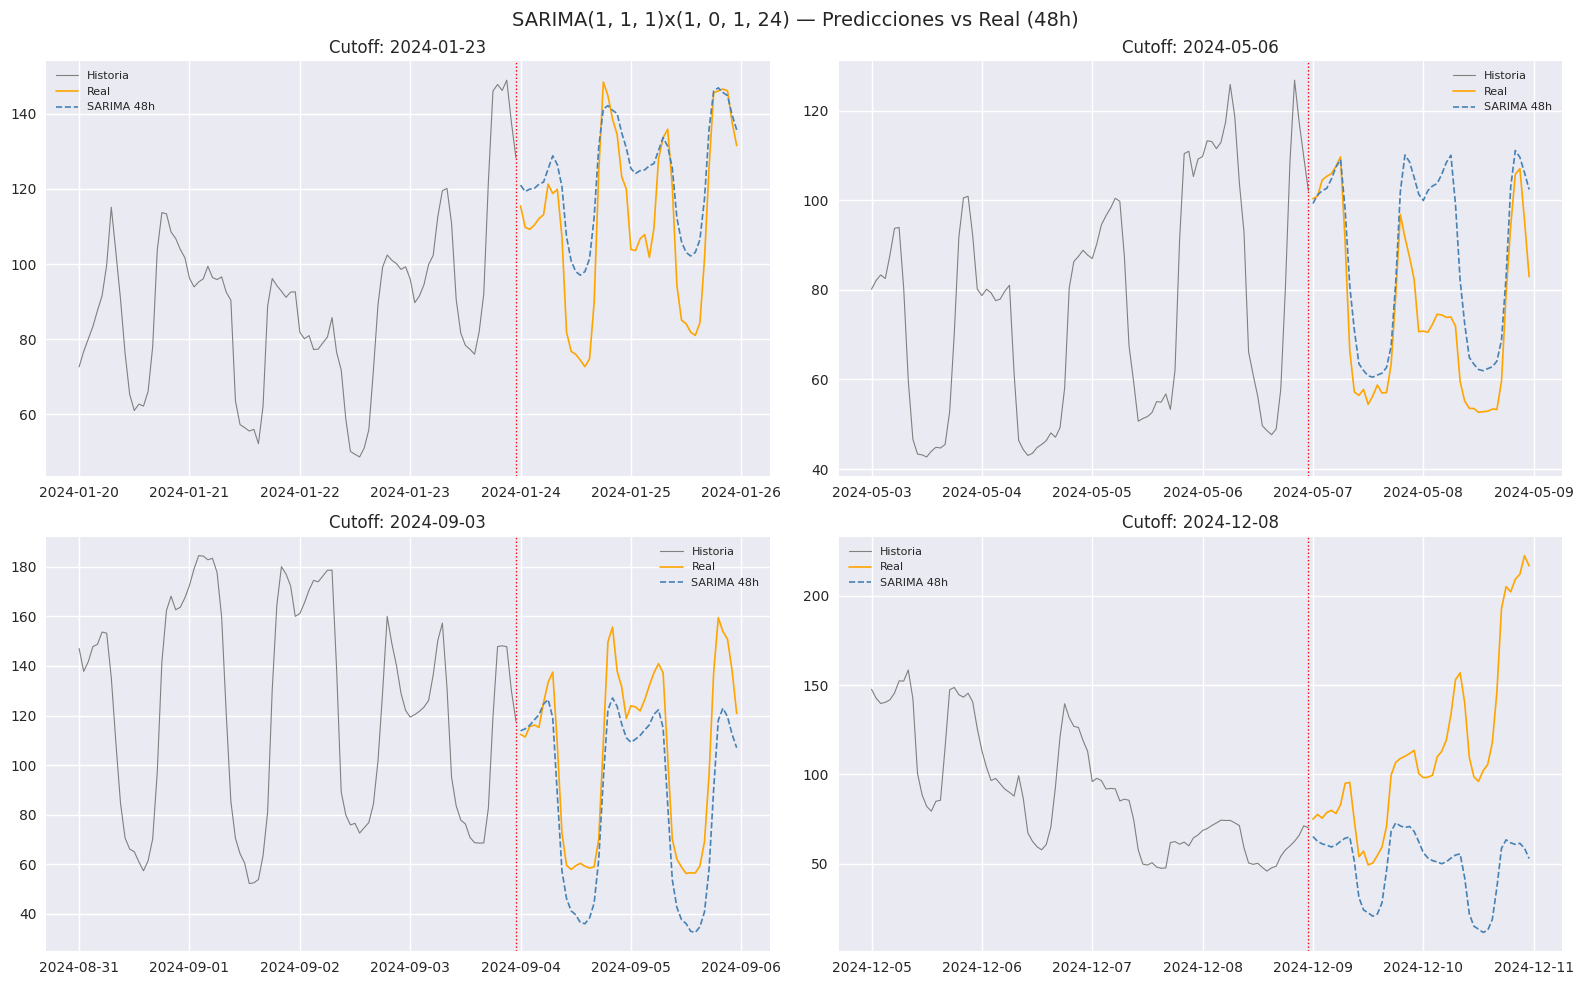

In [9]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle(f"SARIMA{sarima_order}x{sarima_seasonal_order} — Predicciones vs Real (48h)", fontsize=14)

for idx, split_idx in enumerate(PLOT_INDICES):
    ax          = axes[idx // 2][idx % 2]
    fit         = preds_sarima[split_idx]
    cutoff_time = fit["cutoff_time"]
    train_w     = fit["train_window"]
    test        = fit["48h"]["test"]
    pred        = fit["48h"]["pred"]
    history     = train_w.iloc[-4 * SEASONAL_PERIOD:]

    ax.plot(history.index, history.values,
            color="gray", label="Historia", linewidth=0.8)
    ax.plot(test.index, test.values,
            color="orange", label="Real", linewidth=1.2)
    ax.plot(test.index, pred,
            color="steelblue", linestyle="--",
            label="SARIMA 48h", linewidth=1.2)
    ax.axvline(x=cutoff_time, color="red", linestyle=":", linewidth=1)
    ax.set_title(f"Cutoff: {cutoff_time.date()}")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / "sarima_predicciones.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
# Tabla simple de resultados
def build_results_row(ci_df):
    row = {"model": ci_df["model"].iloc[0]}
    for _, r in ci_df.iterrows():
        row[f"MAE_{r['horizon']}"]  = round(r["MAE_mean"], 3)
        row[f"RMSE_{r['horizon']}"] = round(r["RMSE_mean"], 3)
    return row

naive_arima_ci = pd.read_csv(RESULTS_DIR / "comparacion_naive_arima_ci.csv")

resultados_ci = []
for model in naive_arima_ci["model"].unique():
    sub = naive_arima_ci[naive_arima_ci["model"] == model]
    resultados_ci.append(build_results_row(sub))

resultados_ci.append(build_results_row(sarima_ci))

resultados = pd.DataFrame(resultados_ci).set_index("model")
print(resultados)
resultados.to_csv(RESULTS_DIR / "comparacion_naive_arima_sarima.csv")

                               MAE_48h  RMSE_48h  MAE_72h  RMSE_72h
model                                                              
Naive_last                      29.616    35.965   32.524    38.949
Naive_seasonal                  20.837    25.778   23.015    28.349
ARIMA(2, 1, 2)                  26.953    31.767   28.886    33.975
SARIMA(1, 1, 1)x(1, 0, 1, 24)   22.214    26.605   26.801    31.657


## 8. Interpretación de resultados SARIMA

*Pendiente de actualizar con los resultados de la evaluación a resolución horaria.*

El modelo SARIMA con s=24 incorpora la estacionalidad diaria de forma
explícita. Se analizará si la componente estacional mejora sobre ARIMA
y en qué horizonte la diferencia es más significativa, así como si los
intervalos de confianza al 95% se solapan entre ambos modelos.

## 9. Comparación final — Naive, ARIMA y SARIMA

Se combinan los resultados de los tres notebooks anteriores para
comparar todos los modelos evaluados hasta este punto mediante
MAE, RMSE e intervalos de confianza al 95% por bootstrap.
Un modelo es significativamente mejor cuando sus IC no se solapan
con los del modelo de referencia (Naive_seasonal).

In [11]:
naive_arima_ci = pd.read_csv(RESULTS_DIR / "comparacion_naive_arima_ci.csv")

all_ci = pd.concat([naive_arima_ci, sarima_ci], ignore_index=True)

print("\n========== COMPARACIÓN FINAL ==========\n")
for _, r in all_ci.iterrows():
    print(f"{r['model']:35s} {r['horizon']:4s}  "
          f"MAE = {r['MAE_mean']:6.2f} ± {r['MAE_std']:5.2f}  "
          f"IC95% [{r['MAE_ci_lo']:6.2f}, {r['MAE_ci_hi']:6.2f}]  "
          f"(n={int(r['n_eval'])})")

all_ci.to_csv(RESULTS_DIR / "comparacion_naive_arima_sarima_ci.csv", index=False)


========== COMPARACIÓN FINAL ==========

Naive_last                          48h   MAE =  29.62 ± 14.18  IC95% [ 25.60,  33.84]  (n=45)
Naive_last                          72h   MAE =  32.52 ± 16.13  IC95% [ 28.00,  37.54]  (n=45)
Naive_seasonal                      48h   MAE =  20.84 ± 14.78  IC95% [ 16.83,  25.59]  (n=45)
Naive_seasonal                      72h   MAE =  23.01 ± 16.91  IC95% [ 18.37,  28.50]  (n=45)
ARIMA(2, 1, 2)                      48h   MAE =  26.95 ± 12.42  IC95% [ 23.49,  30.95]  (n=45)
ARIMA(2, 1, 2)                      72h   MAE =  28.89 ± 14.41  IC95% [ 24.93,  33.23]  (n=45)
SARIMA(1, 1, 1)x(1, 0, 1, 24)       48h   MAE =  22.21 ± 15.94  IC95% [ 17.93,  27.24]  (n=45)
SARIMA(1, 1, 1)x(1, 0, 1, 24)       72h   MAE =  26.80 ± 19.33  IC95% [ 21.59,  32.94]  (n=45)


## 10. Interpretación de resultados y comparación

*Pendiente de actualizar con los resultados de la evaluación a resolución horaria.*

| Modelo | MAE 48h | MAE 72h | RMSE 48h | RMSE 72h |
|--------|---------|---------|----------|----------|
| Naive_last | -- | -- | -- | -- |
| Naive_seasonal | -- | -- | -- | -- |
| ARIMA | -- | -- | -- | -- |
| SARIMA(auto)[24] | -- | -- | -- | -- |

Se actualizará cuando se completen las evaluaciones a resolución horaria.